# GOAT $U_{XX}$ gate 


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from collections import OrderedDict
from qutip_qoc.objective import Objective
from qutip_qoc.pulse_optim import optimize_pulses

np.set_printoptions(precision=6, suppress=True)

## ops

In [10]:
I2=qt.qeye(2)
sx=0.5*qt.sigmax()
sy=0.5*qt.sigmay()
sz=0.5*qt.sigmaz()

def op_on(q, op):
    ops=[I2,I2,I2]
    ops[q]=op
    return qt.tensor(ops)

# e, n1, n2
Sx,Sy,Sz = op_on(0,sx), op_on(0,sy), op_on(0,sz)
Ix1,Iy1,Iz1 = op_on(1,sx), op_on(1,sy), op_on(1,sz)
Ix2,Iy2,Iz2 = op_on(2,sx), op_on(2,sy), op_on(2,sz)


## target

In [11]:
UXX = 0.5 * np.array([
    [ 1, 0, 0, 1,  1, 0, 0,-1],
    [ 0, 1, 1, 0,  0, 1,-1, 0],
    [ 0, 1, 1, 0,  0,-1, 1, 0],
    [ 1, 0, 0, 1, -1, 0, 0, 1],
    [ 1, 0, 0,-1,  1, 0, 0, 1],
    [ 0, 1,-1, 0,  0, 1, 1, 0],
    [ 0,-1, 1, 0,  0, 1, 1, 0],
    [-1, 0, 0, 1,  1, 0, 0, 1],
], dtype=complex)

U_target = qt.Qobj(UXX, dims=[[2,2,2],[2,2,2]])
U0 = qt.qeye([2,2,2])
print("U_target error=", np.linalg.norm((U_target.dag()*U_target-U0).full()))

U_target error= 0.0


## GOAT model

no raw Zeeman precession, keep entangling 


In [12]:
# coupling (MHz)
A1=95
A2=9

# eff. drift 
H_drift = 2*np.pi*(A1*Sz*Iz1 + A2*Sz*Iz2)

gamma_e = 27.97e3  
gamma_n = 17.23   
eta = gamma_n/gamma_e

Hx = 2*np.pi*(Sx+eta*(Ix1+Ix2))
Hy = 2*np.pi*(Sy+eta * (Iy1+Iy2))

print("eta=gamma_n/gamma_e=", eta)


eta=gamma_n/gamma_e= 0.0006160171612441903


## GOAT cntrls

In [13]:
T = 10     
K = 12             
n_ts = 300
tlist = np.linspace(0, T, n_ts)                    
Amax = 20.0                     
guess_scale = 0.08

def fourier_series(t, p):
    out = p[0]
    for k in range(1, K + 1):
        out += p[(2*k)-1]*np.cos(2*np.pi*k*t/T)
        out += p[2*k]*np.sin(2*np.pi*k*t/T)
    return out

def fourier_grad(t, p, idx):
    if idx==0:
        return 1
    k = (idx+1)//2
    if idx%2==1:
        return np.cos(2*np.pi*k*t/T)
    return np.sin(2*np.pi*k*t/T)

n_params_per_ctrl=(2*K)+1


## Def H

In [14]:
H = [H_drift, [Hx, fourier_series, {"grad": fourier_grad}],
              [Hy, fourier_series, {"grad": fourier_grad}]]

obj = Objective(initial=U0, H=H, target=U_target)


## GOAT run

In [15]:
seed = 0

#params
rng = np.random.default_rng(seed)
params = OrderedDict()
params["Bx"] = {
    "guess": guess_scale*rng.standard_normal(n_params_per_ctrl),
    "bounds": [(-Amax, Amax)]*n_params_per_ctrl}
params["By"] = {
    "guess": guess_scale*rng.standard_normal(n_params_per_ctrl),
    "bounds": [(-Amax, Amax)]*n_params_per_ctrl}

#run
result = optimize_pulses(
    objectives=[obj],
    control_parameters=params,
    tlist=tlist,
    algorithm_kwargs={
        "alg": "GOAT",
        "fid_type": "PSU",
        "fid_err_targ": 1e-4,
        "max_iter": 1000,
    },
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "options": {
            "maxiter": 400,
            "ftol": 1e-12,
            "gtol": 1e-8,
        },
    },
    integrator_kwargs={
        "nsteps": 200000,
        "atol": 1e-9,
        "rtol": 1e-8,
    },
)

print("infid.:", result.infidelity)

infid.: 0.5000659656385629


## Plt

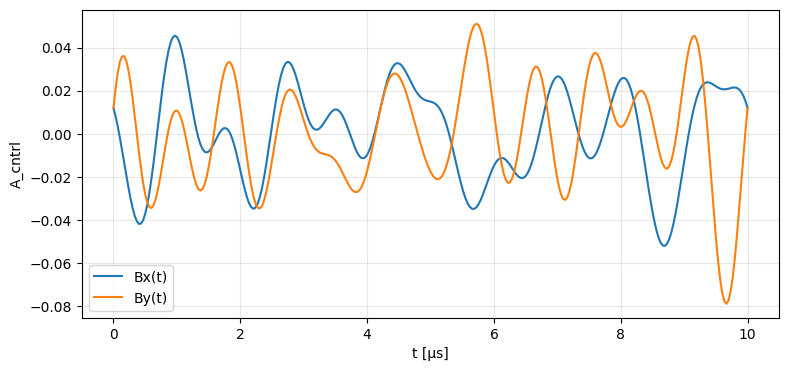

In [16]:
ctrl_Bx = np.array(result.optimized_controls[0])
ctrl_By = np.array(result.optimized_controls[1])

plt.figure(figsize=(9,4))
plt.plot(tlist, ctrl_Bx, label="Bx(t)")
plt.plot(tlist, ctrl_By, label="By(t)")
plt.xlabel("t [µs]")
plt.ylabel("A_cntrl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()